In [6]:
# ── 1. IMPORT ───────────────────────────────────────────────────────────────
import pandas as pd

FILE_PATH = "HR_Dataset_Sanitized.csv"

df = pd.read_csv(FILE_PATH)

print(f"Shape: {df.shape} ({df.shape[0]} rows, {df.shape[1]} columns)")
df.head()


Shape: (311, 32) (311 rows, 32 columns)


,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,Termd,PositionID,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,0,0,1,1,5,4,0,62506,0,19,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,1,1,1,5,3,3,0,104437,1,27,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,1,1,0,5,5,3,0,64955,1,20,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,1,1,0,1,5,3,0,64991,0,19,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,0,2,0,5,5,3,0,50825,1,19,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2


In [7]:
# ── 2. CLEANING ─────────────────────────────────────────────────────────────

# --- 2a. Missing values overview ---
print("=== Missing values by column ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing": missing, "% Missing": missing_pct})
print(missing_df[missing_df["Missing"] > 0].to_string())

# --- 2b. Special case: DateofTermination ---
# This column is empty for active employees (Termd = 0)
# and filled only for employees who have already left (Termd = 1).
print("\n=== Check that DateofTermination is NaN only when Termd = 0 ===")
print(df.groupby("Termd")["DateofTermination"].apply(lambda x: x.isnull().sum()).rename("NaN count"))

# Binary flag documenting whether a termination date exists.
# Keep it for analysis only; do not use it as a predictive feature.
print("\n=== Create HasTermDate (analysis only; not a modeling feature) ===")
df["HasTermDate"] = df["DateofTermination"].notna().astype(int)

# --- 2c. Convert date columns ---
print("\n=== Convert date columns ===")
for col in ["DateofHire", "DateofTermination", "LastPerformanceReview_Date"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")

# --- 2d. Drop non-usable free-text columns ---
print("\n=== Drop ManagerName (free-text field) ===")
COLS_TO_DROP = ["ManagerName"]
df_clean = df.drop(columns=COLS_TO_DROP)

print(f"\nCleaned DataFrame: {df_clean.shape}")
df_clean.dtypes


=== Missing values by column ===
                   Missing  % Missing
DateofTermination      207      66.56
ManagerID                8       2.57

=== Check that DateofTermination is NaN only when Termd = 0 ===
Termd
0    207
1      0
Name: NaN count, dtype: int64

=== Create HasTermDate (analysis only; not a modeling feature) ===

=== Convert date columns ===

=== Drop ManagerName (free-text field) ===

Cleaned DataFrame: (311, 32)


MarriedID                              int64
MaritalStatusID                        int64
GenderID                               int64
EmpStatusID                            int64
DeptID                                 int64
PerfScoreID                            int64
FromDiversityJobFairID                 int64
Salary                                 int64
Termd                                  int64
PositionID                             int64
Position                                 str
State                                    str
Sex                                      str
MaritalDesc                              str
CitizenDesc                              str
HispanicLatino                           str
RaceDesc                                 str
DateofHire                    datetime64[us]
DateofTermination             datetime64[us]
TermReason                               str
EmploymentStatus                         str
Department                               str
ManagerID 

In [13]:
# ── 3. TARGET VARIABLE ──────────────────────────────────────────────────────
# Termd: 0 = active employee | 1 = employee who left

y = df_clean["Termd"]
X = df_clean.drop(columns=["Termd"])

print("=== Target distribution ===")
counts = y.value_counts().rename({0: "Active", 1: "Left"})
print(counts.to_string())
print(f"\nTurnover rate: {y.mean():.1%}")


=== Target distribution ===
Termd
Active    207
Left      104

Turnover rate: 33.4%


=== Quantitative variable analysis ===


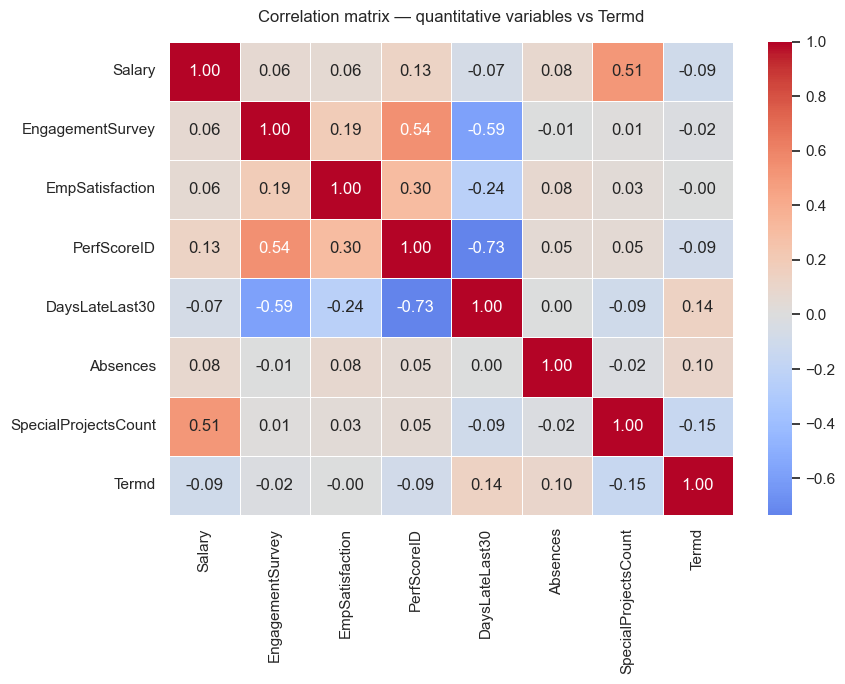

=== Correlation with Termd (sorted) ===
SpecialProjectsCount   -0.147429
DaysLateLast30          0.136379
Absences                0.098274
Salary                 -0.093994
PerfScoreID            -0.089061
EngagementSurvey       -0.017543
EmpSatisfaction        -0.004732


In [14]:
# ── 4. EDA — CORRELATION ANALYSIS ──────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

print("=== Quantitative variable analysis ===")

sns.set_theme(style="whitegrid", palette="muted")

# ── 4a. Correlation among quantitative variables ────────────────────────────
QUANT_COLS = ["Salary", "EngagementSurvey", "EmpSatisfaction",
              "PerfScoreID", "DaysLateLast30", "Absences",
              "SpecialProjectsCount", "Termd"]

corr_matrix = df_clean[QUANT_COLS].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax)
ax.set_title("Correlation matrix — quantitative variables vs Termd", pad=14)
plt.tight_layout()
plt.show()

# Display variables ranked by their correlation with Termd
print("=== Correlation with Termd (sorted) ===")
print(corr_matrix["Termd"].drop("Termd").sort_values(key=abs, ascending=False).to_string())


Overall, linear correlations are fairly weak, so this cell should be used to spot leads rather than draw final conclusions on its own.

=== Qualitative variable analysis ===


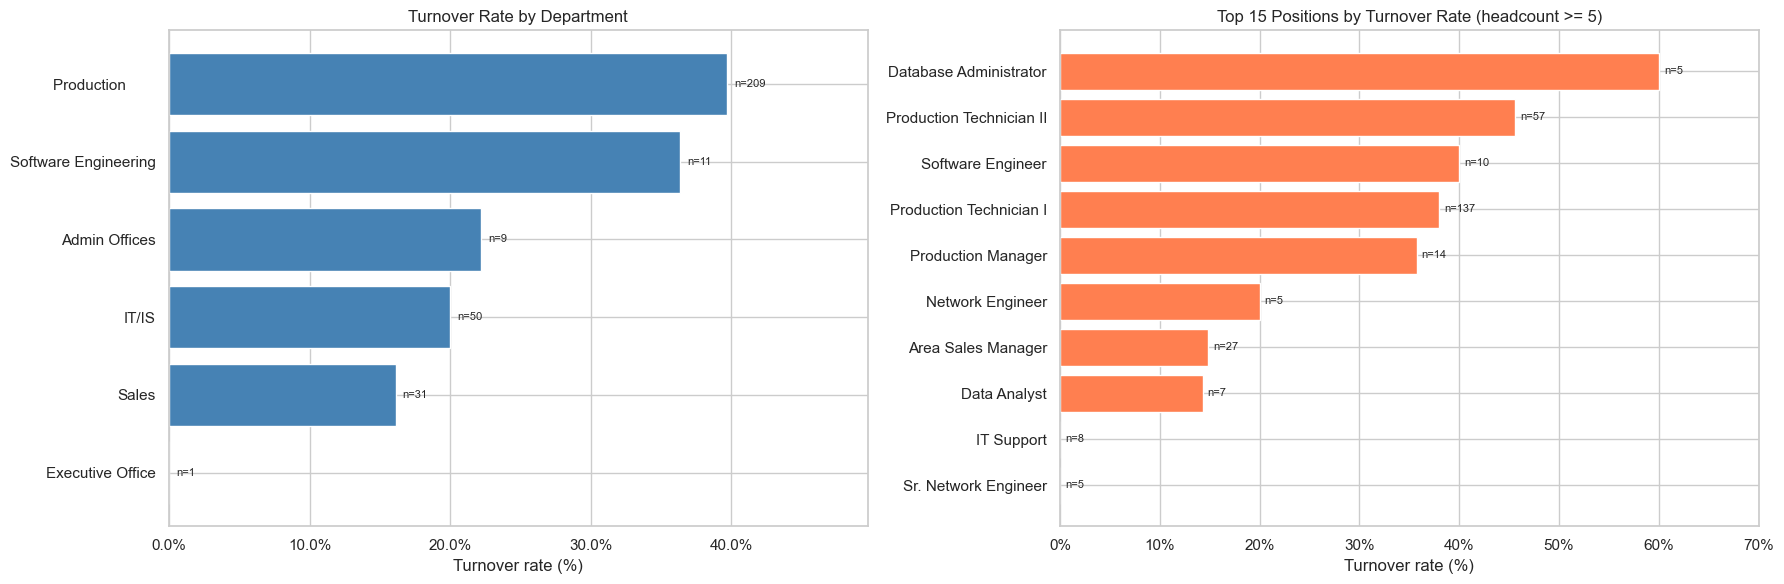

In [15]:
# ── 4b. Turnover Rate by Department and Position ───────────────────────────
print("=== Qualitative variable analysis ===")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Group by department and compute turnover rate + headcount
dept_rate = (df_clean.groupby("Department")["Termd"]
             .agg(["mean", "count"])
             .rename(columns={"mean": "TurnoverRate", "count": "Headcount"})
             .sort_values("TurnoverRate", ascending=False))

# Group by position and exclude very small groups
pos_rate = (df_clean.groupby("Position")["Termd"]
            .agg(["mean", "count"])
            .rename(columns={"mean": "TurnoverRate", "count": "Headcount"})
            .query("Headcount >= 5")
            .sort_values("TurnoverRate", ascending=False)
            .head(15))

def plot_turnover_bars(ax, summary_df, title, color):
    bars = ax.barh(summary_df.index, summary_df["TurnoverRate"] * 100, color=color)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_title(title)
    ax.set_xlabel("Turnover rate (%)")
    ax.set_xlim(0, summary_df["TurnoverRate"].max() * 100 + 10)
    ax.invert_yaxis()

    for bar, (_, row) in zip(bars, summary_df.iterrows()):
        ax.text(bar.get_width() + 0.5,
                bar.get_y() + bar.get_height() / 2,
                f"n={int(row['Headcount'])}",
                va="center", fontsize=8)

plot_turnover_bars(axes[0], dept_rate, "Turnover Rate by Department", "steelblue")
plot_turnover_bars(axes[1], pos_rate, "Top 15 Positions by Turnover Rate (headcount >= 5)", "coral")

plt.tight_layout()
plt.show()


Production has the largest headcount and also shows a relatively high turnover rate.
Software Engineering also stands out with a high turnover rate, but on a much smaller headcount.
On the position side, roles such as Database Administrator or Production Technician II appear more exposed, but those results should always be read together with headcount.

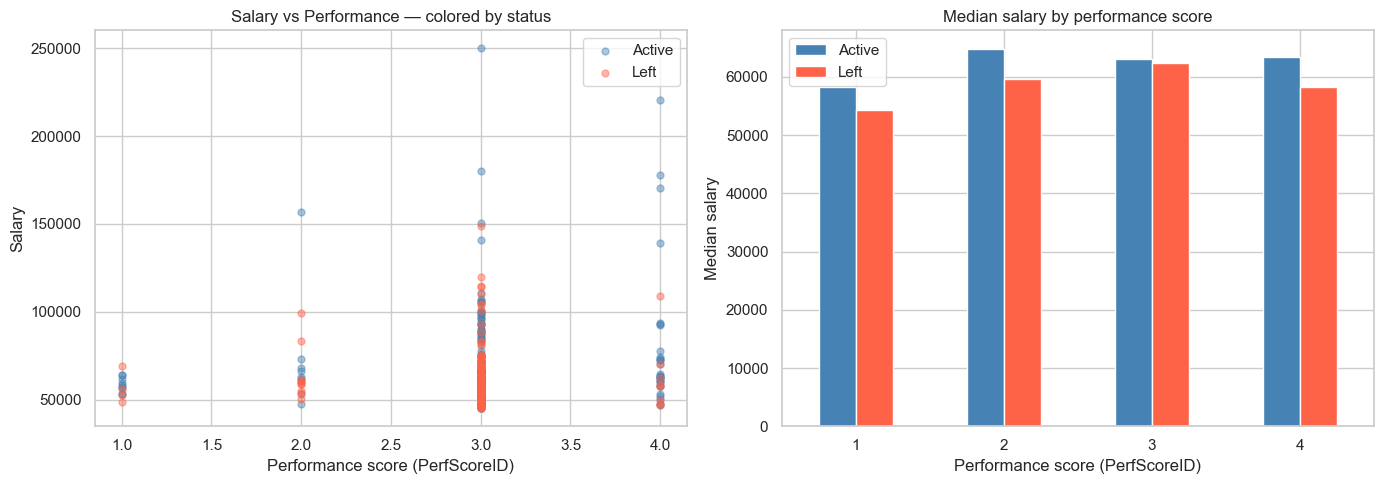

=== Red flags detected (PerfScore >= 3 & Salary <= 58274$) ===
  Number of profiles: 90
  Turnover rate in this group: 38.9% (vs 33.4% overall)


In [16]:
# ── 4c. Red Flags — Low Salary × High Performance ──────────────────────────
# Hypothesis: a highly rated but underpaid employee may be more likely to leave.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Scatter plot: Salary vs PerfScoreID, colored by Termd ---
colors = {0: "steelblue", 1: "tomato"}
labels = {0: "Active", 1: "Left"}

for termd_val, grp in df_clean.groupby("Termd"):
    axes[0].scatter(grp["PerfScoreID"], grp["Salary"],
                    alpha=0.45, s=25,
                    color=colors[termd_val],
                    label=labels[termd_val])

axes[0].set_xlabel("Performance score (PerfScoreID)")
axes[0].set_ylabel("Salary")
axes[0].set_title("Salary vs Performance — colored by status")
axes[0].legend()

# --- Median salary by performance score, split by Termd ---
pivot = df_clean.groupby(["PerfScoreID", "Termd"])["Salary"].median().unstack()
pivot.columns = [labels[c] for c in pivot.columns]
pivot.plot(kind="bar", ax=axes[1], color=["steelblue", "tomato"], edgecolor="white")
axes[1].set_title("Median salary by performance score")
axes[1].set_xlabel("Performance score (PerfScoreID)")
axes[1].set_ylabel("Median salary")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend()

plt.tight_layout()
plt.show()

# --- Numeric summary of the red flag: high PerfScoreID (>= 3) + low Salary ---
low_salary_threshold = df_clean["Salary"].quantile(0.33)
red_flags = df_clean[(df_clean["PerfScoreID"] >= 3) & (df_clean["Salary"] <= low_salary_threshold)]
print(f"=== Red flags detected (PerfScore >= 3 & Salary <= {low_salary_threshold:.0f}$) ===")
print(f"  Number of profiles: {len(red_flags)}")
print(f"  Turnover rate in this group: {red_flags['Termd'].mean():.1%} "
      f"(vs {df_clean['Termd'].mean():.1%} overall)")


We created a business red flag: PerfScoreID >= 3 and Salary in the bottom third.
Results:
The low-salary threshold is about 58,274.
The red-flag group contains 90 profiles.
Its turnover rate is 38.9%, versus 33.4% overall.
This profile therefore looks riskier than average, although the gap remains moderate.

In [8]:
# ── 5. FEATURE ENGINEERING FOR MODELING (LEAK-SAFE) ───────────────────────
model_df = df_clean.copy()

# --- 5a. Tenure calculation without future information leakage ---
# Use a snapshot date available before departure decision:
# LastPerformanceReview_Date (fallback: today's date if missing).
today = pd.Timestamp.today().normalize()
snapshot_date = model_df["LastPerformanceReview_Date"].fillna(today)
model_df["TenureDays"] = (snapshot_date - model_df["DateofHire"]).dt.days.clip(lower=0)
model_df["TenureYears"] = (model_df["TenureDays"] / 365.25).round(2)

# --- 5b. Remove non-predictive / ID-like columns when present ---
id_or_unused_candidates = [
    "Employee_Name", "EmpID", "EmployeeID", "Zip", "ZipCode", "ManagerName", "ManagerID"
]
cols_to_drop = [col for col in id_or_unused_candidates if col in model_df.columns]

# --- 5c. Remove leakage-prone columns (post-event or target proxies) ---
leakage_candidates = [
    "DateofTermination", "HasTermDate", "TermReason", "EmploymentStatus", "EmpStatusID"
]
leakage_to_drop = [col for col in leakage_candidates if col in model_df.columns]

# Also remove raw date fields after tenure feature creation
date_to_drop = [col for col in ["DateofHire", "LastPerformanceReview_Date"] if col in model_df.columns]

model_df = model_df.drop(columns=cols_to_drop + leakage_to_drop + date_to_drop)

# --- 5d. One-hot encoding for categorical variables ---
categorical_cols = model_df.drop(columns=["Termd"]).select_dtypes(include=["object", "string"]).columns.tolist()

X_model = pd.get_dummies(
    model_df.drop(columns=["Termd"]),
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)
y_model = model_df["Termd"].astype(int)

print("=== Leak-safe feature engineering summary ===")
print(f"Rows: {len(model_df)}")
print(f"Columns dropped (ID/unused): {cols_to_drop if cols_to_drop else 'None found'}")
print(f"Columns dropped (leakage-prone): {leakage_to_drop if leakage_to_drop else 'None found'}")
print(f"Columns dropped (raw dates): {date_to_drop if date_to_drop else 'None found'}")
print(f"Categorical columns encoded: {len(categorical_cols)}")
print(f"X_model shape: {X_model.shape}")
print(f"y_model shape: {y_model.shape}")
print(f"TenureYears range: {model_df['TenureYears'].min():.2f} to {model_df['TenureYears'].max():.2f}")

X_model.head()


=== Leak-safe feature engineering summary ===
Rows: 311
Columns dropped (ID/unused): ['ManagerID']
Columns dropped (leakage-prone): ['DateofTermination', 'HasTermDate', 'TermReason', 'EmploymentStatus', 'EmpStatusID']
Columns dropped (raw dates): ['DateofHire', 'LastPerformanceReview_Date']
Categorical columns encoded: 10
X_model shape: (311, 104)
y_model shape: (311,)
TenureYears range: 0.00 to 12.99


,MarriedID,MaritalStatusID,GenderID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,PositionID,EngagementSurvey,EmpSatisfaction,...,RecruitmentSource_Employee Referral,RecruitmentSource_Google Search,RecruitmentSource_Indeed,RecruitmentSource_LinkedIn,RecruitmentSource_On-line Web application,RecruitmentSource_Other,RecruitmentSource_Website,PerformanceScore_Fully Meets,PerformanceScore_Needs Improvement,PerformanceScore_PIP
0,0,0,1,5,4,0,62506,19,4.60,5,...,0,0,0,1,0,0,0,0,0,0
1,1,1,1,3,3,0,104437,27,4.96,3,...,0,0,1,0,0,0,0,1,0,0
2,1,1,0,5,3,0,64955,20,3.02,3,...,0,0,0,1,0,0,0,1,0,0
3,1,1,0,5,3,0,64991,19,4.84,5,...,0,0,1,0,0,0,0,1,0,0
4,0,2,0,5,3,0,50825,19,5.00,4,...,0,1,0,0,0,0,0,1,0,0


- Tenure is computed from `DateofHire` to a pre-event snapshot (`LastPerformanceReview_Date`), not to termination date.
- Leakage-prone fields (`DateofTermination`, `HasTermDate`, `TermReason`, `EmploymentStatus`, `EmpStatusID`) are removed before training.
- All remaining text categories are transformed into binary indicator columns using one-hot encoding.
- The final leak-safe `X_model` and `y_model` are ready for train/test split and baseline model training.


This section provides:

1. The exact columns removed at each preprocessing step.
2. Human-readable mappings for numeric ID columns (for example, DeptID -> Department).
3. One-hot encoding interpretation for categorical variables with more than two categories, including the dropped baseline category when drop_first=True.


In [9]:
# ── 5.1 DROPPED COLUMNS + ENCODING/ID REFERENCE ────────────────────────────
from IPython.display import display

print("=== 5.1A Dropped columns by step ===")

# Step 2 (cleaning)
step2_candidates = ["ManagerName"]
step2_dropped = [c for c in step2_candidates if c in df.columns]

# Step 5 (modeling prep)
step5_id_dropped = cols_to_drop if "cols_to_drop" in globals() else []
step5_leakage_dropped = leakage_to_drop if "leakage_to_drop" in globals() else []
step5_date_dropped = date_to_drop if "date_to_drop" in globals() else []

drop_report = pd.DataFrame([
    {"Step": "Step 2 - cleaning", "DroppedColumns": ", ".join(step2_dropped) if step2_dropped else "None"},
    {"Step": "Step 5b - ID/non-predictive", "DroppedColumns": ", ".join(step5_id_dropped) if step5_id_dropped else "None"},
    {"Step": "Step 5c - leakage-prone", "DroppedColumns": ", ".join(step5_leakage_dropped) if step5_leakage_dropped else "None"},
    {"Step": "Step 5c - raw dates", "DroppedColumns": ", ".join(step5_date_dropped) if step5_date_dropped else "None"},
    {
        "Step": "Total (unique)",
        "DroppedColumns": ", ".join(sorted(set(step2_dropped + step5_id_dropped + step5_leakage_dropped + step5_date_dropped)))
        if (step2_dropped or step5_id_dropped or step5_leakage_dropped or step5_date_dropped) else "None"
    }
])
display(drop_report)

print("\n=== 5.1B ID to label mapping (what each ID means) ===")
id_label_pairs = [
    ("DeptID", "Department"),
    ("PositionID", "Position"),
    ("PerfScoreID", "PerformanceScore"),
    ("EmpStatusID", "EmploymentStatus"),
    ("MaritalStatusID", "MaritalDesc"),
    ("GenderID", "Sex")
]

for id_col, label_col in id_label_pairs:
    if id_col in df.columns and label_col in df.columns:
        raw_map = (
            df[[id_col, label_col]]
            .dropna()
            .assign(**{label_col: lambda d: d[label_col].astype(str).str.strip()})
        )

        # Canonical mapping: most frequent label for each ID
        canonical_map = (
            raw_map.groupby([id_col, label_col]).size().reset_index(name="Count")
            .sort_values([id_col, "Count", label_col], ascending=[True, False, True])
            .drop_duplicates(subset=[id_col], keep="first")
        )

        label_counts = raw_map.groupby(id_col)[label_col].nunique().rename("DistinctLabels")
        canonical_map = canonical_map.merge(label_counts, on=id_col, how="left")
        canonical_map = canonical_map.rename(columns={id_col: "ID", label_col: "CanonicalLabel"}).sort_values("ID")

        print(f"\n{id_col} -> {label_col} (canonical mapping)")
        display(canonical_map[["ID", "CanonicalLabel", "Count", "DistinctLabels"]].reset_index(drop=True))

        ambiguous = canonical_map[canonical_map["DistinctLabels"] > 1]
        if not ambiguous.empty:
            print(f"Warning: {len(ambiguous)} IDs map to multiple labels in the raw data. "
                  "Canonical label above is the most frequent one.")
            display(ambiguous[["ID", "CanonicalLabel", "DistinctLabels"]].reset_index(drop=True))

print("\n=== 5.1C One-hot interpretation for variables with >2 categories ===")
onehot_rows = []

for col in categorical_cols:
    categories = sorted(model_df[col].dropna().astype(str).str.strip().unique().tolist())
    if len(categories) <= 2:
        continue

    prefix = f"{col}_"
    encoded_levels = sorted([c[len(prefix):].strip() for c in X_model.columns if c.startswith(prefix)])
    baseline_candidates = [cat for cat in categories if cat not in encoded_levels]
    baseline = baseline_candidates[0] if len(baseline_candidates) == 1 else ", ".join(baseline_candidates)

    onehot_rows.append({
        "OriginalColumn": col,
        "NumCategories": len(categories),
        "DroppedBaseline": baseline,
        "NumDummiesCreated": len(encoded_levels),
        "InterpretationRule": f"Each dummy {prefix}<level>: 1 if {col}=<level>, else 0. If all dummies are 0, category is '{baseline}'."
    })

onehot_ref_df = pd.DataFrame(onehot_rows).sort_values("OriginalColumn").reset_index(drop=True)
display(onehot_ref_df)


=== 5.1A Dropped columns by step ===


,Step,DroppedColumns
0,Step 2 - cleaning,ManagerName
1,Step 5b - ID/non-predictive,ManagerID
2,Step 5c - leakage-prone,"DateofTermination, HasTermDate, TermReason, Em..."
3,Step 5c - raw dates,"DateofHire, LastPerformanceReview_Date"
4,Total (unique),"DateofHire, DateofTermination, EmpStatusID, Em..."



=== 5.1B ID to label mapping (what each ID means) ===

DeptID -> Department (canonical mapping)


,ID,CanonicalLabel,Count,DistinctLabels
0,1,Admin Offices,9,2
1,2,Executive Office,1,1
2,3,IT/IS,50,1
3,4,Software Engineering,10,1
4,5,Production,208,1
5,6,Sales,31,2


,ID,CanonicalLabel,DistinctLabels
0,1,Admin Offices,2
1,6,Sales,2


...

,ID,CanonicalLabel,Count,DistinctLabels
0,0,Single,137,1
1,1,Married,124,1
2,2,Divorced,30,1
3,3,Separated,12,1
4,4,Widowed,8,1



GenderID -> Sex (canonical mapping)


,ID,CanonicalLabel,Count,DistinctLabels
0,0,F,176,1
1,1,M,135,1



=== 5.1C One-hot interpretation for variables with >2 categories ===


,OriginalColumn,NumCategories,DroppedBaseline,NumDummiesCreated,InterpretationRule
0,CitizenDesc,3,Eligible NonCitizen,2,Each dummy CitizenDesc_<level>: 1 if CitizenDe...
1,Department,6,Admin Offices,5,Each dummy Department_<level>: 1 if Department...
2,HispanicLatino,4,No,3,Each dummy HispanicLatino_<level>: 1 if Hispan...
3,MaritalDesc,5,Divorced,4,Each dummy MaritalDesc_<level>: 1 if MaritalDe...
4,PerformanceScore,4,Exceeds,3,Each dummy PerformanceScore_<level>: 1 if Perf...
5,Position,31,Accountant I,31,Each dummy Position_<level>: 1 if Position=<le...
6,RaceDesc,6,American Indian or Alaska Native,5,Each dummy RaceDesc_<level>: 1 if RaceDesc=<le...
7,RecruitmentSource,9,CareerBuilder,8,Each dummy RecruitmentSource_<level>: 1 if Rec...
8,State,28,AL,27,"Each dummy State_<level>: 1 if State=<level>, ..."


## 6. Step 4 - Random Forest Training and Evaluation (Leak-Safe)

In this section, we:

1. Split the leak-safe dataset into 80% train and 20% test.
2. Train a Random Forest classifier.
3. Evaluate precision, recall, and F1-score (with special focus on recall for class `1 = Left`).
4. Inspect feature importance after leakage-prone variables are removed.


=== Random Forest Evaluation (positive class = Left) ===
Train size: 248 | Test size: 63
Precision: 1.000
Recall:    0.667
F1-score:  0.800

=== Classification report ===
              precision    recall  f1-score   support

      Active       0.86      1.00      0.92        42
        Left       1.00      0.67      0.80        21

    accuracy                           0.89        63
   macro avg       0.93      0.83      0.86        63
weighted avg       0.90      0.89      0.88        63

=== Confusion matrix [[TN, FP], [FN, TP]] ===
[[42  0]
 [ 7 14]]

=== Top 15 most important features ===
                        Feature  Importance
                     TenureDays    0.180069
                    TenureYears    0.179550
                         Salary    0.072456
               EngagementSurvey    0.056825
                       Absences    0.056436
                     PositionID    0.029200
     RecruitmentSource_LinkedIn    0.028303
                EmpSatisfaction    0.025932
R

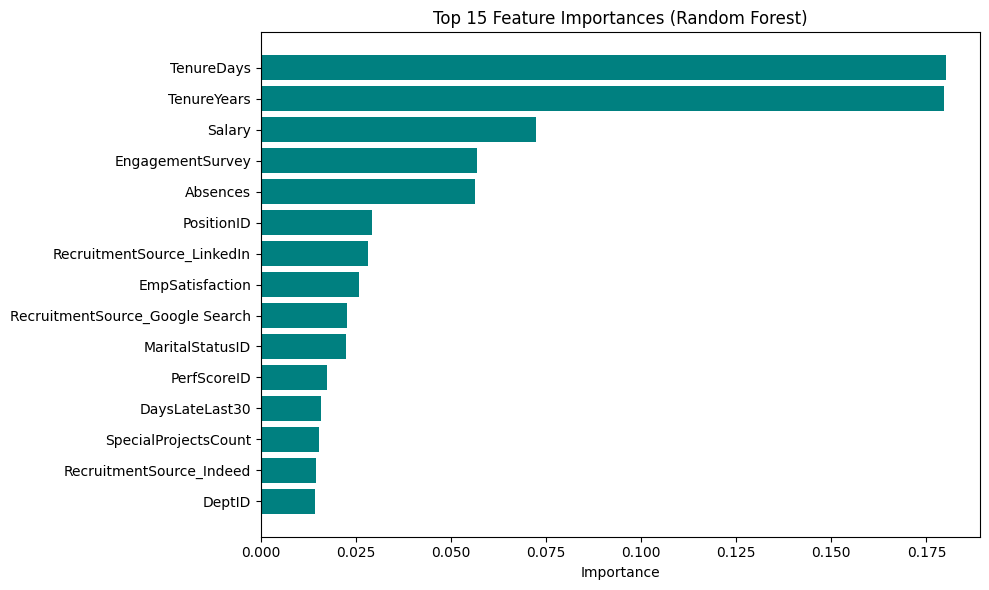

In [10]:
# ── 6. RANDOM FOREST MODEL TRAINING ────────────────────────────────────────
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix

# 80/20 split with class stratification
X_train, X_test, y_train, y_test = train_test_split(
    X_model, y_model,
    test_size=0.20,
    random_state=42,
    stratify=y_model
)

# Random Forest (robust model + feature importance)
rf_model = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

# Evaluation metrics for class 1 (employee who left)
precision = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
recall = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)

print("=== Random Forest Evaluation (positive class = Left) ===")
print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")

print("\n=== Classification report ===")
print(classification_report(y_test, y_pred, target_names=["Active", "Left"], zero_division=0))

print("=== Confusion matrix [[TN, FP], [FN, TP]] ===")
print(confusion_matrix(y_test, y_pred))

# Feature importance ranking
importance_df = (
    pd.DataFrame({
        "Feature": X_model.columns,
        "Importance": rf_model.feature_importances_
    })
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

top_k = 15
top_features = importance_df.head(top_k)

print(f"\n=== Top {top_k} most important features ===")
print(top_features.to_string(index=False))

# Quick chart
plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"][::-1], top_features["Importance"][::-1], color="teal")
plt.title(f"Top {top_k} Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


In [11]:
# ── 7. STEP 5 - MODEL CARD (AUTOGENERATED) ─────────────────────────────────
from IPython.display import Markdown, display

# Build top-10 factor list from feature importance
top10 = importance_df.head(10).copy()

# Short helper to format ranked factors
def _ranked_factor_lines(df):
    lines = []
    for i, (_, row) in enumerate(df.iterrows(), start=1):
        lines.append(f"{i}. {row['Feature']} (importance={row['Importance']:.4f})")
    return "\n".join(lines)

model_card_text = f"""
## Model Card - Employee Turnover Prediction (Leak-Safe)

### 1) Model Type
- **Algorithm:** Random Forest Classifier
- **Task:** Binary classification (`Termd`: 0 = Active, 1 = Left)

### 2) Intended Use
- Decision-support tool for HR teams to anticipate turnover risk.
- Helps prioritize retention actions and interviews for at-risk employees.
- Not intended to make fully automated HR decisions without human review.

### 3) Data and Features
- Source: sanitized/synthetic HR dataset.
- Input table after leak-safe preprocessing: `X_model` with shape **{X_model.shape}**.
- Target: `y_model` with shape **{y_model.shape}**.
- Includes engineered tenure features (`TenureDays`, `TenureYears`) computed from a pre-event snapshot date.
- Excludes leakage-prone fields (`DateofTermination`, `HasTermDate`, `TermReason`, `EmploymentStatus`, `EmpStatusID`).

### 4) Evaluation Snapshot
- Train/Test split: **80/20** with stratification.
- Precision (Left class): **{precision:.3f}**
- Recall (Left class): **{recall:.3f}**
- F1-score (Left class): **{f1:.3f}**

> Recall is prioritized here: missing a true future resignation is typically more costly than a false alert.

### 5) Key Influencing Factors (Top 10)
{_ranked_factor_lines(top10)}

### 6) Limitations and Risks
- The model is trained on synthetic/sanitized data; real-world performance may differ.
- ID/category inconsistencies exist in the raw dataset for some coded fields.
- Correlation and feature importance do not prove causality.
- Should be complemented by qualitative analysis (e.g., NLP on exit interviews, manager notes, survey comments).
- Must be monitored for drift, fairness, and changing HR policies over time.

### 7) Operational Recommendation
- Use the model as an early-warning indicator.
- Combine scores with HR expert review and contextual business knowledge.
"""

display(Markdown(model_card_text))



## Model Card - Employee Turnover Prediction (Leak-Safe)

### 1) Model Type
- **Algorithm:** Random Forest Classifier
- **Task:** Binary classification (`Termd`: 0 = Active, 1 = Left)

### 2) Intended Use
- Decision-support tool for HR teams to anticipate turnover risk.
- Helps prioritize retention actions and interviews for at-risk employees.
- Not intended to make fully automated HR decisions without human review.

### 3) Data and Features
- Source: sanitized/synthetic HR dataset.
- Input table after leak-safe preprocessing: `X_model` with shape **(311, 104)**.
- Target: `y_model` with shape **(311,)**.
- Includes engineered tenure features (`TenureDays`, `TenureYears`) computed from a pre-event snapshot date.
- Excludes leakage-prone fields (`DateofTermination`, `HasTermDate`, `TermReason`, `EmploymentStatus`, `EmpStatusID`).

### 4) Evaluation Snapshot
- Train/Test split: **80/20** with stratification.
- Precision (Left class): **1.000**
- Recall (Left class): **0.667**
- F1-score (Left class): **0.800**

> Recall is prioritized here: missing a true future resignation is typically more costly than a false alert.

### 5) Key Influencing Factors (Top 10)
1. TenureDays (importance=0.1801)
2. TenureYears (importance=0.1795)
3. Salary (importance=0.0725)
4. EngagementSurvey (importance=0.0568)
5. Absences (importance=0.0564)
6. PositionID (importance=0.0292)
7. RecruitmentSource_LinkedIn (importance=0.0283)
8. EmpSatisfaction (importance=0.0259)
9. RecruitmentSource_Google Search (importance=0.0227)
10. MaritalStatusID (importance=0.0224)

### 6) Limitations and Risks
- The model is trained on synthetic/sanitized data; real-world performance may differ.
- ID/category inconsistencies exist in the raw dataset for some coded fields.
- Correlation and feature importance do not prove causality.
- Should be complemented by qualitative analysis (e.g., NLP on exit interviews, manager notes, survey comments).
- Must be monitored for drift, fairness, and changing HR policies over time.

### 7) Operational Recommendation
- Use the model as an early-warning indicator.
- Combine scores with HR expert review and contextual business knowledge.
